<a href="https://colab.research.google.com/github/abeernasim/Crime-Python-Analysis/blob/main/Crimes_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

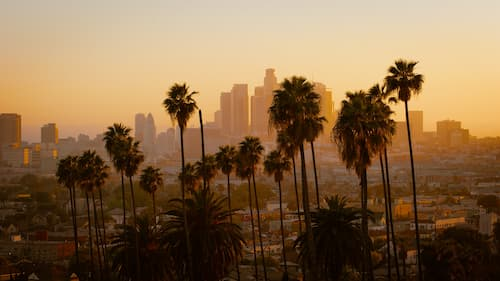

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World!

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [ ]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as ply
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


# **Data Cleaning**

---



# Checking Duplicates

In [ ]:
crimes.duplicated().sum()


np.int64(0)

No duplicates

# Checking Missing Values


In [ ]:
missing_values = crimes.isnull().sum()
missing_values

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,2
Vict Descent,0
Weapon Desc,13595


## **Victim Sex and Weapon Desc seem to have missing values**

**Victim Sex**

In [ ]:
print("Missing 'Vict Sex' values:")
print(crimes['Vict Sex'].isnull().sum())

Missing 'Vict Sex' values:
2


In [ ]:
print("Rows with missing 'Vict Sex' (should be empty after filling):")
display(crimes[crimes['Vict Sex'].isnull()])

Rows with missing 'Vict Sex' (should be empty after filling):


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
3457,221615369,2022-12-21,2022-12-19,0800,Foothill,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",21,NaN,H,NaN,Invest Cont,11000 ARMINTA ST
15004,220314540,2022-08-01,2022-07-30,0300,Southwest,THEFT PLAIN - PETTY ($950 & UNDER),21,NaN,B,NaN,Invest Cont,2400 S WESTERN AV


**Weapon Description**

In [ ]:
print("Missing 'Weapon Desc' values:")
print(crimes['Weapon Desc'].isnull().sum())

Missing 'Weapon Desc' values:
13595


In [ ]:
print("Rows with missing 'Weapon Desc' (should be empty after filling):")
display(crimes[crimes['Weapon Desc'].isnull()])

Rows with missing 'Weapon Desc' (should be empty after filling):


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
21428,221512013,2022-07-08,2022-07-05,1300,N Hollywood,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",42,M,W,NaN,Invest Cont,5700 CRANER AV
21430,221513591,2022-08-09,2022-08-03,2125,N Hollywood,THEFT OF IDENTITY,48,F,W,NaN,Invest Cont,13000 SHERMAN WY
21431,220615328,2022-08-28,2022-08-28,0700,Hollywood,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",31,M,I,NaN,Invest Cont,2000 N HIGHLAND AV
21432,220916545,2022-11-26,2022-11-24,1815,Van Nuys,VIOLATION OF RESTRAINING ORDER,59,F,H,NaN,Adult Other,13900 COHASSET ST


# Handling Missing Values

In [ ]:
# Display rows with missing 'Vict Sex'
print("Rows with missing 'Vict Sex':")
display(crimes[crimes['Vict Sex'].isnull()])

Rows with missing 'Vict Sex':


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
3457,221615369,2022-12-21,2022-12-19,0800,Foothill,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",21,NaN,H,NaN,Invest Cont,11000 ARMINTA ST
15004,220314540,2022-08-01,2022-07-30,0300,Southwest,THEFT PLAIN - PETTY ($950 & UNDER),21,NaN,B,NaN,Invest Cont,2400 S WESTERN AV


In [ ]:
crimes['Vict Sex'].fillna('M', inplace=True)
print("Missing 'Vict Sex' values after filling:")
print(crimes['Vict Sex'].isnull().sum())

Missing 'Vict Sex' values after filling:
0


In [ ]:
print("Rows with missing 'Weapon Desc':")
display(crimes[crimes['Weapon Desc'].isnull()])

Rows with missing 'Weapon Desc':


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
21428,221512013,2022-07-08,2022-07-05,1300,N Hollywood,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",42,M,W,NaN,Invest Cont,5700 CRANER AV
21430,221513591,2022-08-09,2022-08-03,2125,N Hollywood,THEFT OF IDENTITY,48,F,W,NaN,Invest Cont,13000 SHERMAN WY
21431,220615328,2022-08-28,2022-08-28,0700,Hollywood,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",31,M,I,NaN,Invest Cont,2000 N HIGHLAND AV
21432,220916545,2022-11-26,2022-11-24,1815,Van Nuys,VIOLATION OF RESTRAINING ORDER,59,F,H,NaN,Adult Other,13900 COHASSET ST


In [ ]:
crimes['Weapon Desc'].fillna('Unidentified Weapon', inplace=True)
print("Missing 'Weapon Desc' values after filling:")
print(crimes['Weapon Desc'].isnull().sum())

Missing 'Weapon Desc' values after filling:
0


In [ ]:
crimes.head(10)


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,Unidentified Weapon,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,Unidentified Weapon,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,Unidentified Weapon,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,Unidentified Weapon,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,Unidentified Weapon,Invest Cont,1200 W 7TH ST
5,221216052,2022-07-07,2020-02-23,1000,77th Street,THEFT OF IDENTITY,28,F,B,Unidentified Weapon,Invest Cont,500 W 75TH ST
6,221515929,2022-10-10,2020-04-01,1200,N Hollywood,THEFT OF IDENTITY,33,M,W,Unidentified Weapon,Invest Cont,5700 CARTWRIGHT AV
7,231906599,2023-03-03,2020-01-14,1335,Mission,THEFT OF IDENTITY,35,M,O,Unidentified Weapon,Invest Cont,14500 WILLOWGREEN LN
8,231207476,2023-02-27,2020-08-15,0001,77th Street,BURGLARY,72,M,B,Unidentified Weapon,Invest Cont,8800 HAAS AV
9,231506571,2023-03-03,2020-07-15,1700,N Hollywood,OTHER MISCELLANEOUS CRIME,21,F,W,VERBAL THREAT,Invest Cont,12300 EMELITA ST


Checking there is no missing values anymore

In [ ]:
crimes.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Weapon Desc,0


No Missing Values

## Data Analysis

---



# **Commonest Crime Type and Trends Over Time**

First, let's convert the 'DATE OCC' column to datetime objects to enable proper temporal analysis.

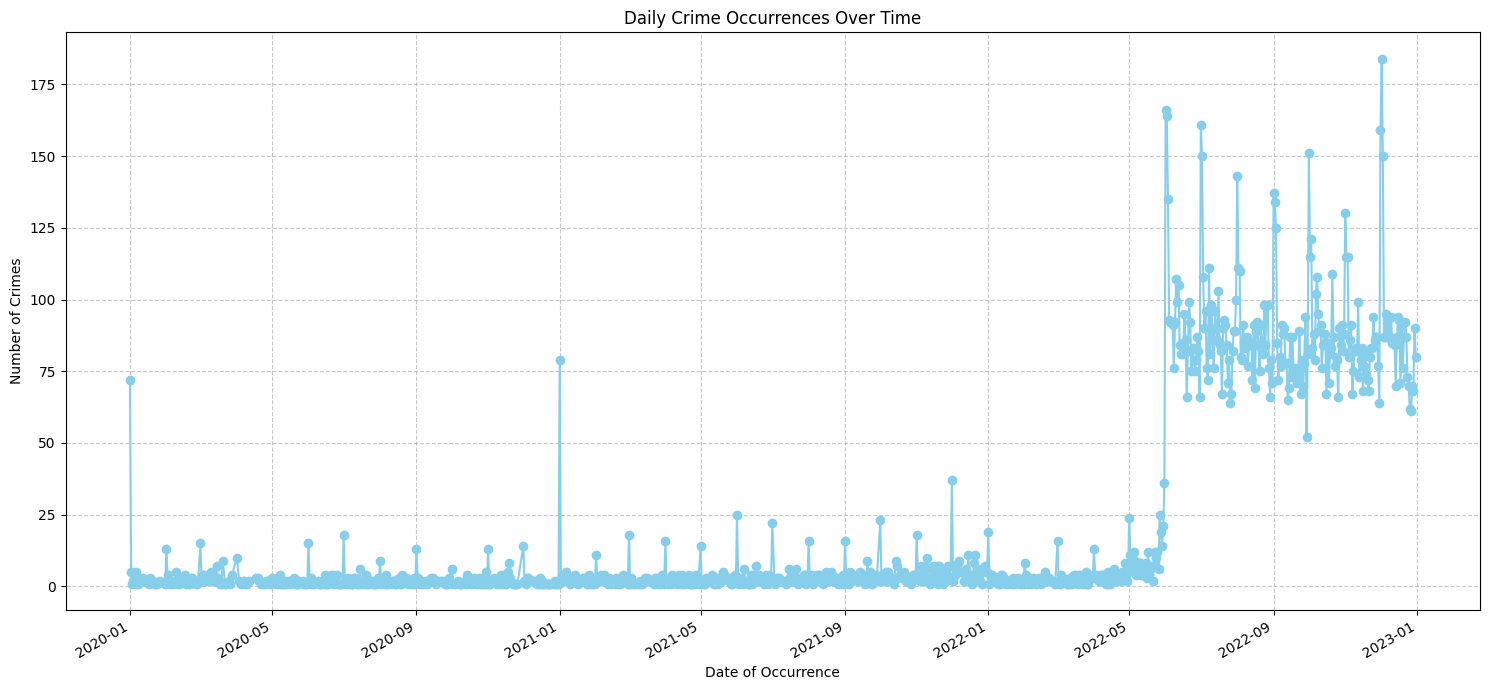


Average crimes in first half: 2.83
Average crimes in second half: 42.11
Crime rates appear to be generally increasing over the observed period.


In [ ]:
# Convert 'DATE OCC' to datetime objects for accurate temporal analysis
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])

# Group by date of occurrence and count crimes
daily_crime_counts = crimes['DATE OCC'].value_counts().sort_index()

# Plotting the crime rates over time
plt.figure(figsize=(15, 7))
daily_crime_counts.plot(kind='line', marker='o', linestyle='-', color='skyblue')
plt.title('Daily Crime Occurrences Over Time')
plt.xlabel('Date of Occurrence')
plt.ylabel('Number of Crimes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# To determine if rates are increasing or decreasing, we can look at a longer trend or specific periods
# For a simple assessment, we can compare the average of the first and last parts of the data.
if len(daily_crime_counts) > 0:
    first_half_avg = daily_crime_counts.iloc[:len(daily_crime_counts)//2].mean()
    second_half_avg = daily_crime_counts.iloc[len(daily_crime_counts)//2:].mean()
    print(f"\nAverage crimes in first half: {first_half_avg:.2f}")
    print(f"Average crimes in second half: {second_half_avg:.2f}")

    if second_half_avg > first_half_avg:
        print("Crime rates appear to be generally increasing over the observed period.")
    elif second_half_avg < first_half_avg:
        print("Crime rates appear to be generally decreasing over the observed period.")
    else:
        print("Crime rates appear to be stable over the observed period.")
else:
    print("No daily crime data to analyze trends.")

**Crime rates appear to be generally increasing over the observed period.**

### Prevailing Crime Type in the Second Half of the Data

Based on the previous analysis, the dataset was divided into two halves to assess crime rate trends. Now, we will focus on the second half to identify the most common type of crime during that period.

In [ ]:
# Get the start date of the second half from the daily_crime_counts index
if len(daily_crime_counts) > 0:
    second_half_start_date = daily_crime_counts.index[len(daily_crime_counts) // 2]
    print(f"The second half of the data for crime analysis starts from: {second_half_start_date.strftime('%Y-%m-%d')}")

    # Filter the crimes DataFrame to include only the second half
    crimes_second_half = crimes[crimes['DATE OCC'] >= second_half_start_date]

    # Determine the most prevailing type of crime in this second half
    if not crimes_second_half.empty:
        prevailing_crime_second_half = crimes_second_half['Crm Cd Desc'].mode()[0]
        prevailing_crime_count = crimes_second_half['Crm Cd Desc'].value_counts().max()
        print(f"\nThe prevailing type of crime in the second half (where average crime was {second_half_avg:.2f}) is: '{prevailing_crime_second_half}' with {prevailing_crime_count} occurrences.")
    else:
        print("No crime data found in the second half to determine prevailing type.")
else:
    print("Cannot determine prevailing crime type as there is no daily crime data available.")

The second half of the data for crime analysis starts from: 2021-08-19

The prevailing type of crime in the second half (where average crime was 42.11) is: 'THEFT OF IDENTITY' with 2935 occurrences.


### Time of Day Analysis for Crimes

Now, let's determine the time when most and least crimes occur by analyzing the 'TIME OCC' column.

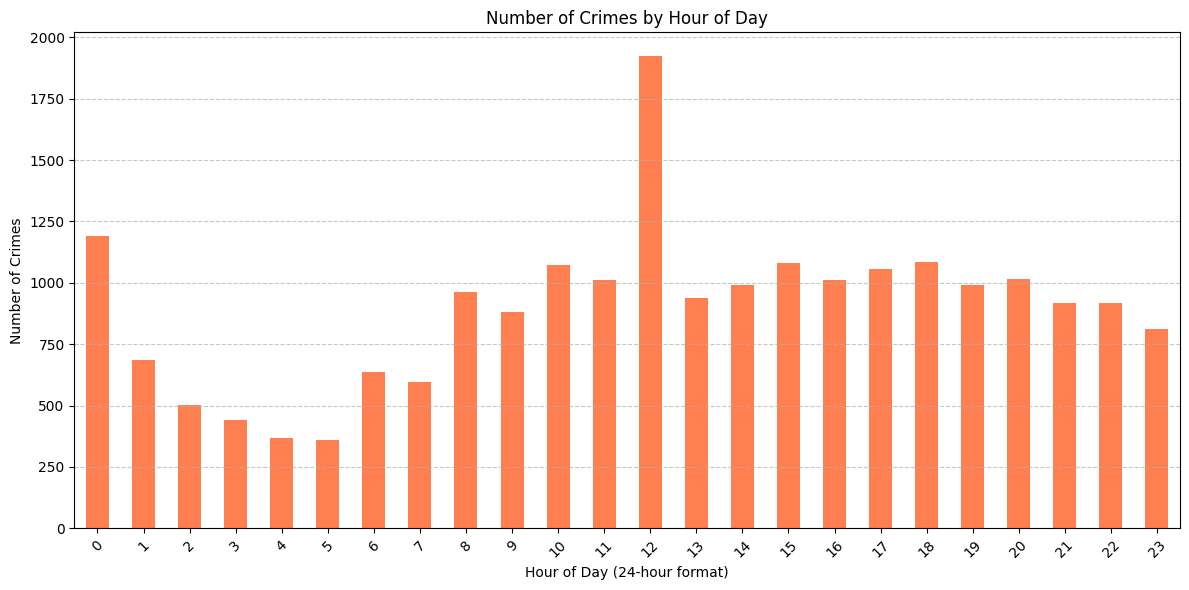


The hour with the most crimes is 12:00 (with 1924 crimes).
The hour with the least crimes is 05:00 (with 360 crimes).


In [ ]:
# Ensure 'TIME OCC' is treated as string for consistency then convert to integer hour
# Pad with leading zeros if necessary to ensure 4 digits, then extract hour
crimes['TIME OCC'] = crimes['TIME OCC'].astype(str).str.zfill(4)
crimes['HOUR OCC'] = crimes['TIME OCC'].str[:2].astype(int)

# Count crimes per hour
hourly_crime_counts = crimes['HOUR OCC'].value_counts().sort_index()

# Plotting hourly crime distribution
plt.figure(figsize=(12, 6))
hourly_crime_counts.plot(kind='bar', color='coral')
plt.title('Number of Crimes by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Find the time when most crimes occur
most_common_hour = hourly_crime_counts.idxmax()
max_crimes = hourly_crime_counts.max()
print(f"\nThe hour with the most crimes is {most_common_hour:02d}:00 (with {max_crimes} crimes).")

# Find the time when least crimes occur
least_common_hour = hourly_crime_counts.idxmin()
min_crimes = hourly_crime_counts.min()
print(f"The hour with the least crimes is {least_common_hour:02d}:00 (with {min_crimes} crimes).")

### Prevailing Crime Types at Specific Hours (Noon and 5 AM)

Now, let's drill down into the crime types that are most common during the peak crime hour (noon) and the hour with the least crimes (5 AM).

In [ ]:
# Prevailing crime at 12:00 (noon)
crimes_noon = crimes[crimes['HOUR OCC'] == 12]
if not crimes_noon.empty:
    prevailing_crime_noon = crimes_noon['Crm Cd Desc'].mode()[0]
    count_noon = crimes_noon['Crm Cd Desc'].value_counts().max()
    print(f"\nThe prevailing type of crime at 12:00 (noon) is: '{prevailing_crime_noon}' with {count_noon} occurrences.")
else:
    print("No crimes recorded at 12:00 (noon).")

# Prevailing crime at 05:00 (5 AM)
crimes_5am = crimes[crimes['HOUR OCC'] == 5]
if not crimes_5am.empty:
    prevailing_crime_5am = crimes_5am['Crm Cd Desc'].mode()[0]
    count_5am = crimes_5am['Crm Cd Desc'].value_counts().max()
    print(f"\nThe prevailing type of crime at 05:00 (5 AM) is: '{prevailing_crime_5am}' with {count_5am} occurrences.")
else:
    print("No crimes recorded at 05:00 (5 AM).")


The prevailing type of crime at 12:00 (noon) is: 'THEFT OF IDENTITY' with 695 occurrences.

The prevailing type of crime at 05:00 (5 AM) is: 'THEFT OF IDENTITY' with 49 occurrences.


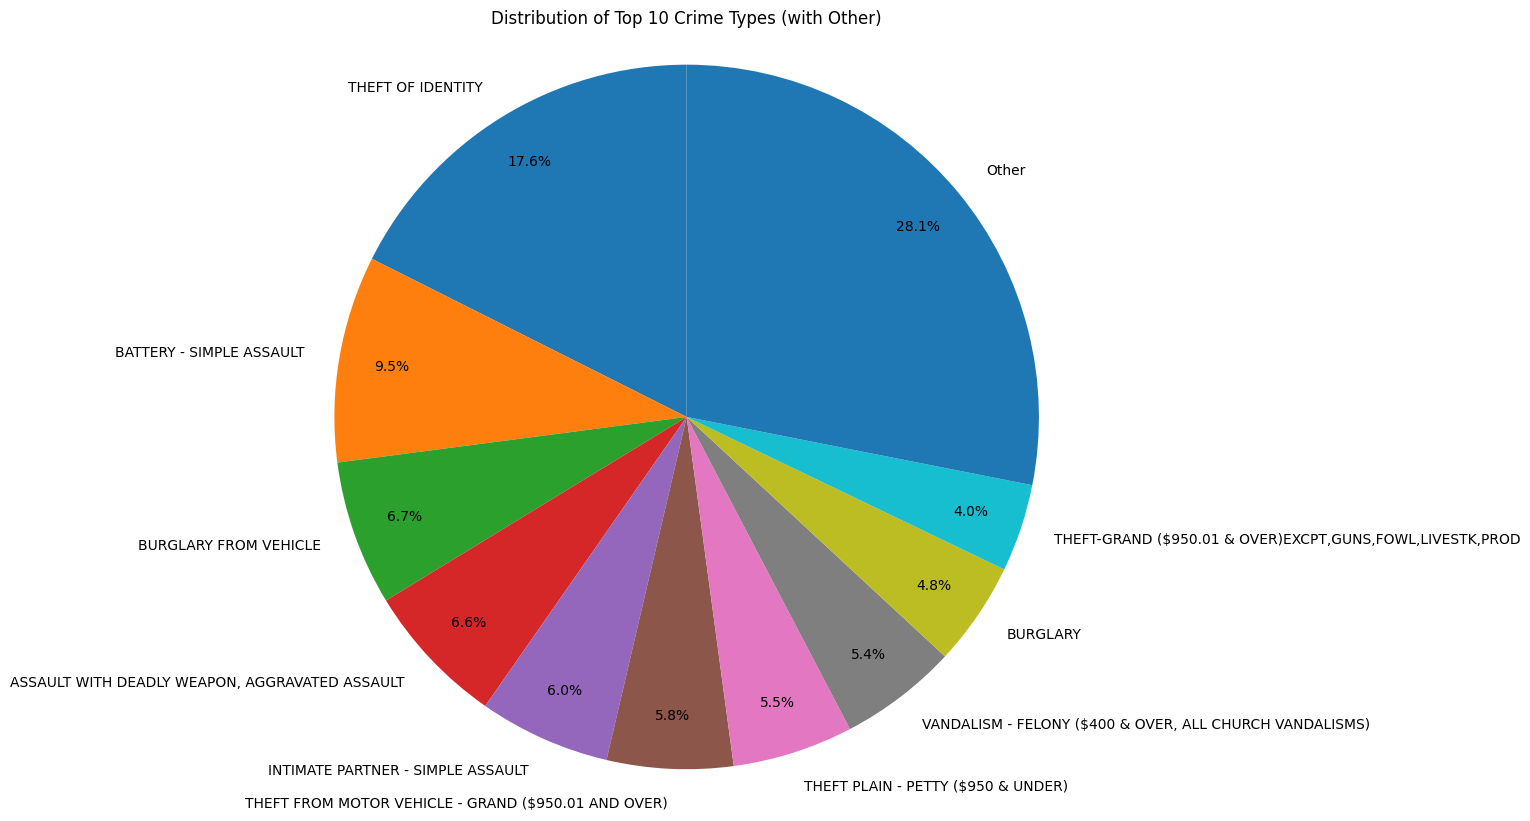


The most common crime types are:
Crm Cd Desc
THEFT OF IDENTITY                                 3771
BATTERY - SIMPLE ASSAULT                          2031
BURGLARY FROM VEHICLE                             1427
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    1412
INTIMATE PARTNER - SIMPLE ASSAULT                 1293
Name: count, dtype: int64


### **Analysis of Crime Types**

Our analysis of crime types reveals that **'THEFT OF IDENTITY'** is the most prevalent crime across the dataset. This crime type also remains the most common during both the peak crime hour (12:00 noon) and the hour with the least crime (05:00 AM), although with significantly fewer occurrences at 5 AM. This consistent prevalence of 'THEFT OF IDENTITY' highlights its widespread nature across different times of the day.

## Conclusion of Crime Type Temporal Analysis

Based on our analysis of the Los Angeles crime data:

*   **Crime Trends**: There appears to be a general **increase in crime rates** over the observed period, with the average number of crimes in the second half of the dataset significantly higher than in the first half.
*   **Prevailing Crime Type**: In the second half of the data and in the hottest time of the day when crime rate peaks, the **'THEFT OF IDENTITY'** was the most prevailing crime type, accounting for 2935 occurrences.

> Add blockquote


*   **Recommendation**: increase the working police on identity protection and educate the force on building intel to protect identity verification

----------

# **Geographic Crime Analysis**

In [ ]:
# Determine Top 10 Areas by Crime Volume
area_crime_counts = crimes['AREA NAME'].value_counts()
top_10_areas = area_crime_counts.head(10)

print("Top 10 Areas by Crime Volume and Most Prevalent Crime Type:")
print("-----------------------------------------------------------")

# Prepare data for visualization (though visualization part is removed, this DataFrame is still useful)
plot_data = []

# For each of the top 10 areas, find the most prevalent crime type
for area in top_10_areas.index:
    # Filter crimes for the current area
    crimes_in_area = crimes[crimes['AREA NAME'] == area]

    # Find the most prevalent crime type in this area
    if not crimes_in_area.empty:
        most_prevalent_crime = crimes_in_area['Crm Cd Desc'].mode()[0]
        crime_count = crimes_in_area['Crm Cd Desc'].value_counts().max()
        print(f"Area: {area} (Total Crimes: {top_10_areas[area]}\n  Most Prevalent Crime: '{most_prevalent_crime}' ({crime_count} occurrences)\n")
        plot_data.append({'Area': area, 'Total Crimes': top_10_areas[area], 'Most Prevalent Crime': most_prevalent_crime})
    else:
        print(f"Area: {area} (Total Crimes: {top_10_areas[area]}\n  No crime data available for this area.\n")
        plot_data.append({'Area': area, 'Total Crimes': top_10_areas[area], 'Most Prevalent Crime': 'N/A'})

# Create a DataFrame for plotting (this DataFrame will be available for a separate visualization cell)
plot_df = pd.DataFrame(plot_data)

Top 10 Areas by Crime Volume and Most Prevalent Crime Type:
-----------------------------------------------------------
Area: Central (Total Crimes: 1625
  Most Prevalent Crime: 'BURGLARY FROM VEHICLE' (303 occurrences)

Area: 77th Street (Total Crimes: 1390
  Most Prevalent Crime: 'THEFT OF IDENTITY' (321 occurrences)

Area: Southwest (Total Crimes: 1355
  Most Prevalent Crime: 'THEFT OF IDENTITY' (251 occurrences)

Area: Hollywood (Total Crimes: 1163
  Most Prevalent Crime: 'BATTERY - SIMPLE ASSAULT' (152 occurrences)

Area: Pacific (Total Crimes: 1078
  Most Prevalent Crime: 'THEFT OF IDENTITY' (137 occurrences)

Area: Southeast (Total Crimes: 1043
  Most Prevalent Crime: 'THEFT OF IDENTITY' (269 occurrences)

Area: Newton (Total Crimes: 1042
  Most Prevalent Crime: 'THEFT OF IDENTITY' (221 occurrences)

Area: Van Nuys (Total Crimes: 1040
  Most Prevalent Crime: 'THEFT OF IDENTITY' (167 occurrences)

Area: Olympic (Total Crimes: 1024
  Most Prevalent Crime: 'THEFT OF IDENTITY' (138 

/tmp/ipykernel_10286/4108968010.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Total Crimes', y='Area', data=plot_df, palette='viridis') # Swapped x and y


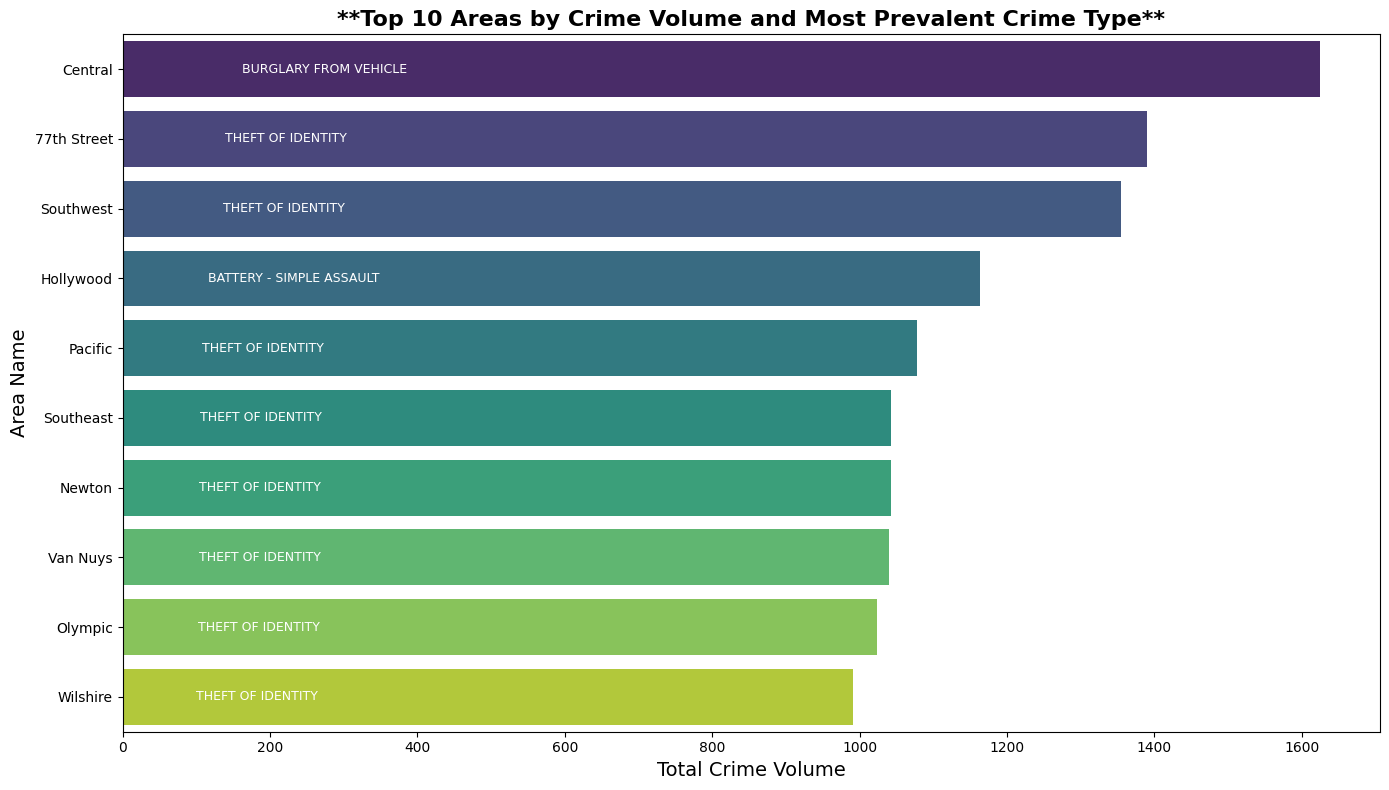

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the visualization
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Total Crimes', y='Area', data=plot_df, palette='viridis') # Swapped x and y
plt.xlabel('Total Crime Volume', fontsize=14) # Increased font size
plt.ylabel('Area Name', fontsize=14)       # Increased font size
plt.title('**Top 10 Areas by Crime Volume and Most Prevalent Crime Type**', fontsize=16, fontweight='bold') # Increased font size and made bold

# Add text labels for most prevalent crime type inside the bars
for index, row in plot_df.iterrows():
    ax.text(
        row['Total Crimes'] * 0.1, # Place text at 10% of the bar length (x-coordinate)
        index,                    # Y-coordinate remains the index
        row['Most Prevalent Crime'],
        color='white',            # Use white text for better visibility on dark bars
        ha="left",                # Align text to the left within the bar
        va="center",              # Vertically center the text
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Conclusion on Top Crime Areas

Our analysis identifies the **top 10 areas with the highest crime volumes** in Los Angeles. These areas, such as Central, 77th Street, and Southwest, consistently show a high number of reported incidents.

Interestingly, **'THEFT OF IDENTITY'** remains a highly prevalent crime type across many of these top areas, including 77th Street, Southwest, Pacific, Southeast, Newton, Van Nuys, Olympic, and Wilshire. This indicates a widespread issue of identity theft across different geographic divisions.

However, other areas exhibit different dominant crime types:
*   **Central** district's most prevalent crime is **'BURGLARY FROM VEHICLE'**.
*   **Hollywood**'s most common crime is **'BATTERY - SIMPLE ASSAULT'**.
Recommendtion:While identity theft is a pervasive concern, specific areas may require targeted resource allocation to address their unique primary crime challenges, such as property crimes in Central and assault in Hollywood.

--------------

# **Victim Analysis**

Determining the most targeted age group of victims and their gender and race would help deteremine most vaulnerable group and aid in using resources to study why are they targeted and protect them.

In [ ]:
# 1. Analyze Victim Age Distribution
print("\n--- Victim Age Distribution ---")
print(crimes['Vict Age'].describe())

# 2. Analyze Victim Sex Distribution
print("\n--- Victim Sex Distribution ---")
# Correct 'H' in 'Vict Sex' to 'X' (assuming 'H' is another form of unknown/error)
crimes['Vict Sex'] = crimes['Vict Sex'].replace('H', 'X')
vict_sex_counts = crimes['Vict Sex'].value_counts()
print(vict_sex_counts)

# 3. Analyze Victim Descent Distribution (Top 10)
print("\n--- Victim Descent Distribution (Top 10) ---")
vict_descent_counts = crimes['Vict Descent'].value_counts().head(10)
print(vict_descent_counts)

# 4. Analyze Top Targeted Groups by Age, Gender, and Race (Top 10 combinations)
print("\n--- Top 10 Targeted Groups by Age, Sex, and Descent ---")
# Group by all three columns and count occurrences
top_targeted_groups = crimes.groupby(['Vict Age', 'Vict Sex', 'Vict Descent']).size().nlargest(10)
print(top_targeted_groups)



--- Victim Age Distribution ---
count    21435.000000
mean        40.164777
std         15.498849
min          2.000000
25%         28.000000
50%         37.000000
75%         50.000000
max         99.000000
Name: Vict Age, dtype: float64

--- Victim Sex Distribution ---
Vict Sex
M    10744
F    10399
X      292
Name: count, dtype: int64

--- Victim Descent Distribution (Top 10) ---
Vict Descent
H    8439
W    5210
B    4136
O    1917
A     620
X     484
K     168
C     157
F     133
J      45
Name: count, dtype: int64

--- Top 10 Targeted Groups by Age, Sex, and Descent ---
Vict Age  Vict Sex  Vict Descent
21        X         X               210
24        M         H               158
31        F         H               146
28        F         H               142
29        F         H               140
30        F         H               138
25        F         H               135
29        M         H               134
33        F         H               129
30        M         H   

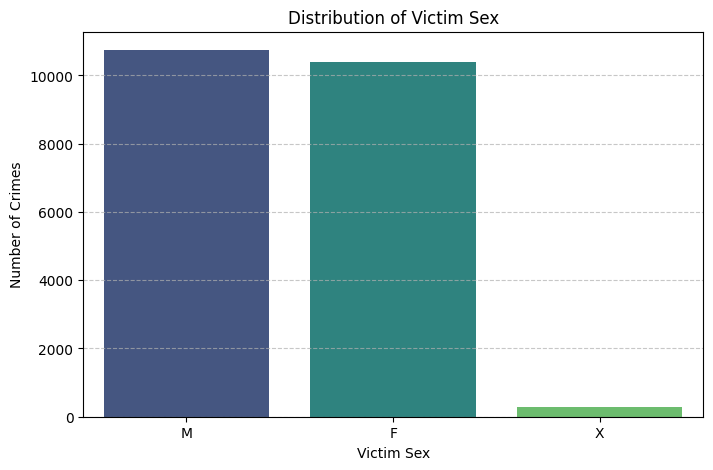

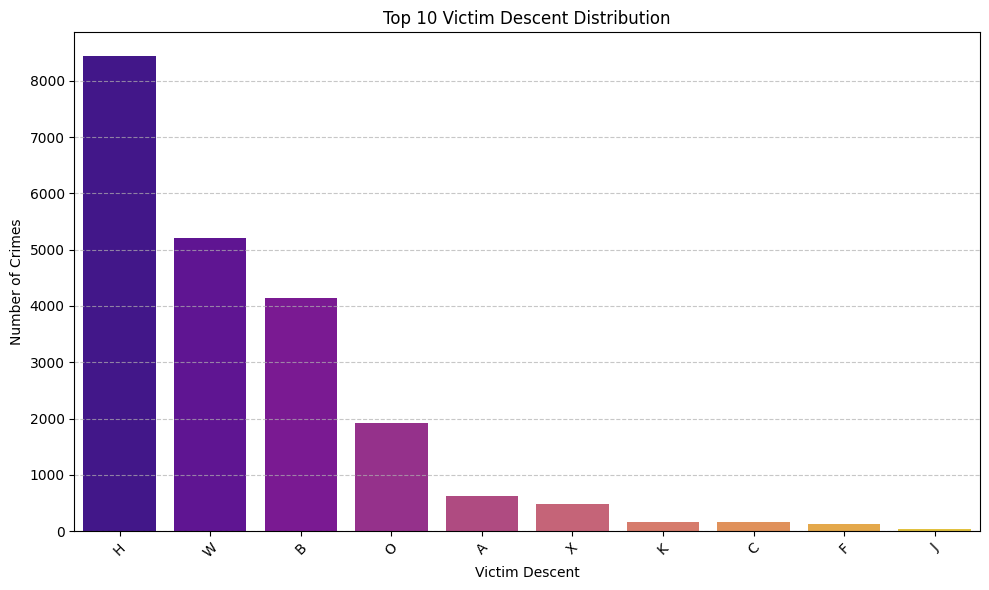

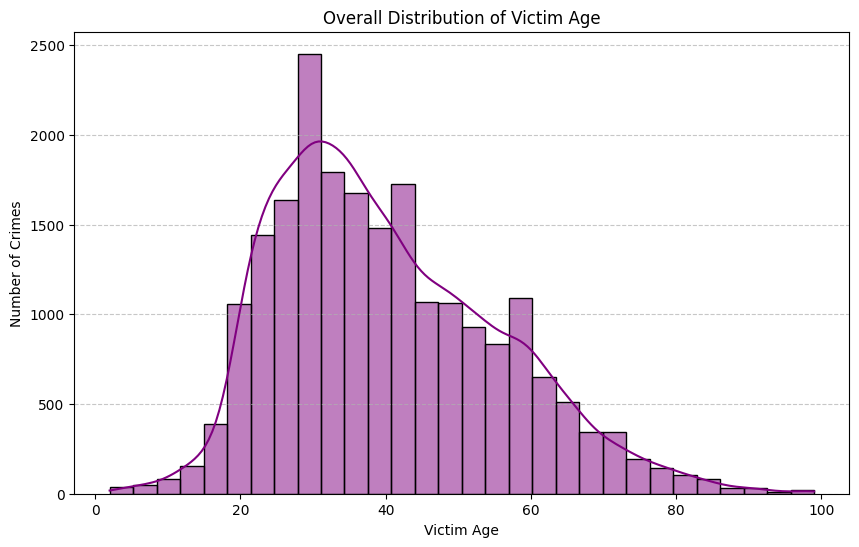

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1: Victim Sex Distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=vict_sex_counts.index, y=vict_sex_counts.values, hue=vict_sex_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Victim Sex')
plt.xlabel('Victim Sex')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualization 2: Victim Descent Distribution (Top 10)
plt.figure(figsize=(10, 6))
sns.barplot(x=vict_descent_counts.index, y=vict_descent_counts.values, hue=vict_descent_counts.index, palette='plasma', legend=False)
plt.title('Top 10 Victim Descent Distribution')
plt.xlabel('Victim Descent')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualization 3: Victim Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=crimes, x='Vict Age', bins=30, kde=True, color='purple')
plt.title('Overall Distribution of Victim Age')
plt.xlabel('Victim Age')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

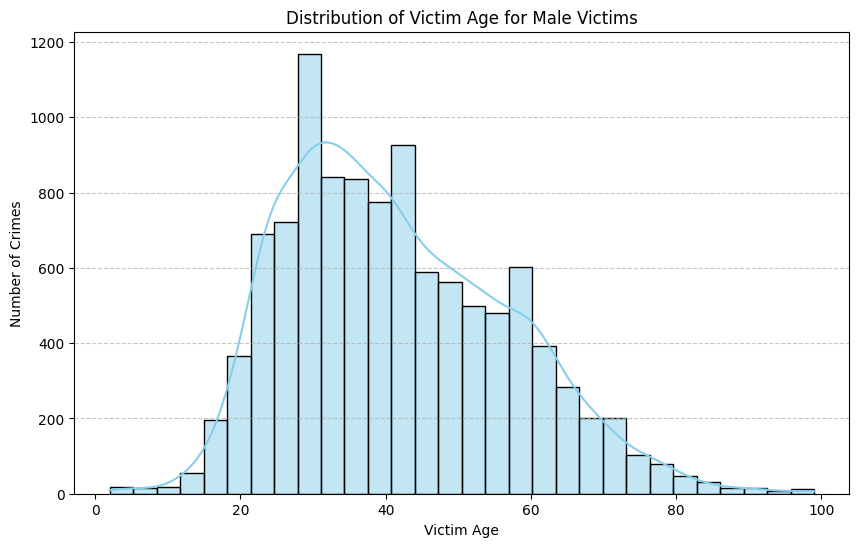

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Male victims
male_victims = crimes[crimes['Vict Sex'] == 'M']

plt.figure(figsize=(10, 6))
sns.histplot(data=male_victims, x='Vict Age', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Victim Age for Male Victims')
plt.xlabel('Victim Age')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

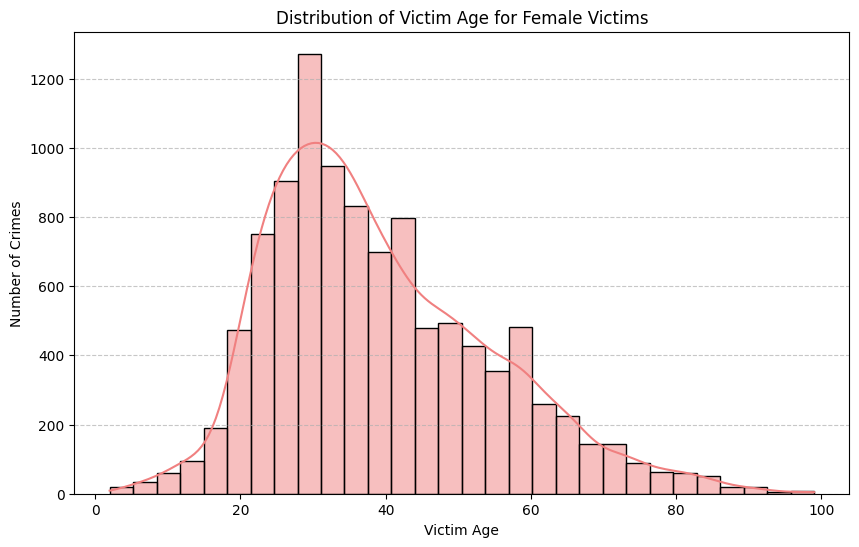

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Female victims
female_victims = crimes[crimes['Vict Sex'] == 'F']

plt.figure(figsize=(10, 6))
sns.histplot(data=female_victims, x='Vict Age', bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Victim Age for Female Victims')
plt.xlabel('Victim Age')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusion on Victim Demographics

Our analysis of victim demographics reveals several key insights:

*   **Victim Age**:The overall age distribution shows a peak in young to middle-aged adults. Specifically, 50% of victims fall within the **28 to 50 years** age bracket (between the 25th and 75th percentiles), indicating that this age range contains the highest number of victims.

*   **Victim Sex**: Crimes are almost evenly split between **Male (M)** and **Female (F)** victims, with slightly more male victims.

*   **Victim Descent**: The most frequently targeted victim descent categories are **Hispanic/Latin/Mexican (H)**, followed by **White (W)** and **Black (B)**, reflecting the demographic composition of Los Angeles.

*   **Top Targeted Groups**: When considering age, sex, and descent together, specific combinations show higher vulnerability. For instance, **individuals aged 21 with unknown sex and descent ('X')** appear frequently, suggesting potential data entry issues or specific circumstances for these crimes such as victims withholding ful crime reporting. Additionally, young to middle-aged **Hispanic males and females** (e.g., 24-year-old Male Hispanic, 31-year-old Female Hispanic) are prominently featured among the top targeted groups.

These findings suggest that while crime affects a broad demographic, certain groups, particularly those within the 20-40 age range and of Hispanic descent, may warrant more focused attention and protective measures.

## Crime Data Dashboard

/tmp/ipykernel_3735/2137073216.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crimes['Vict Sex'].fillna('X', inplace=True) # Fill any remaining NaN if not already handled
/tmp/ipykernel_3735/2137073216.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

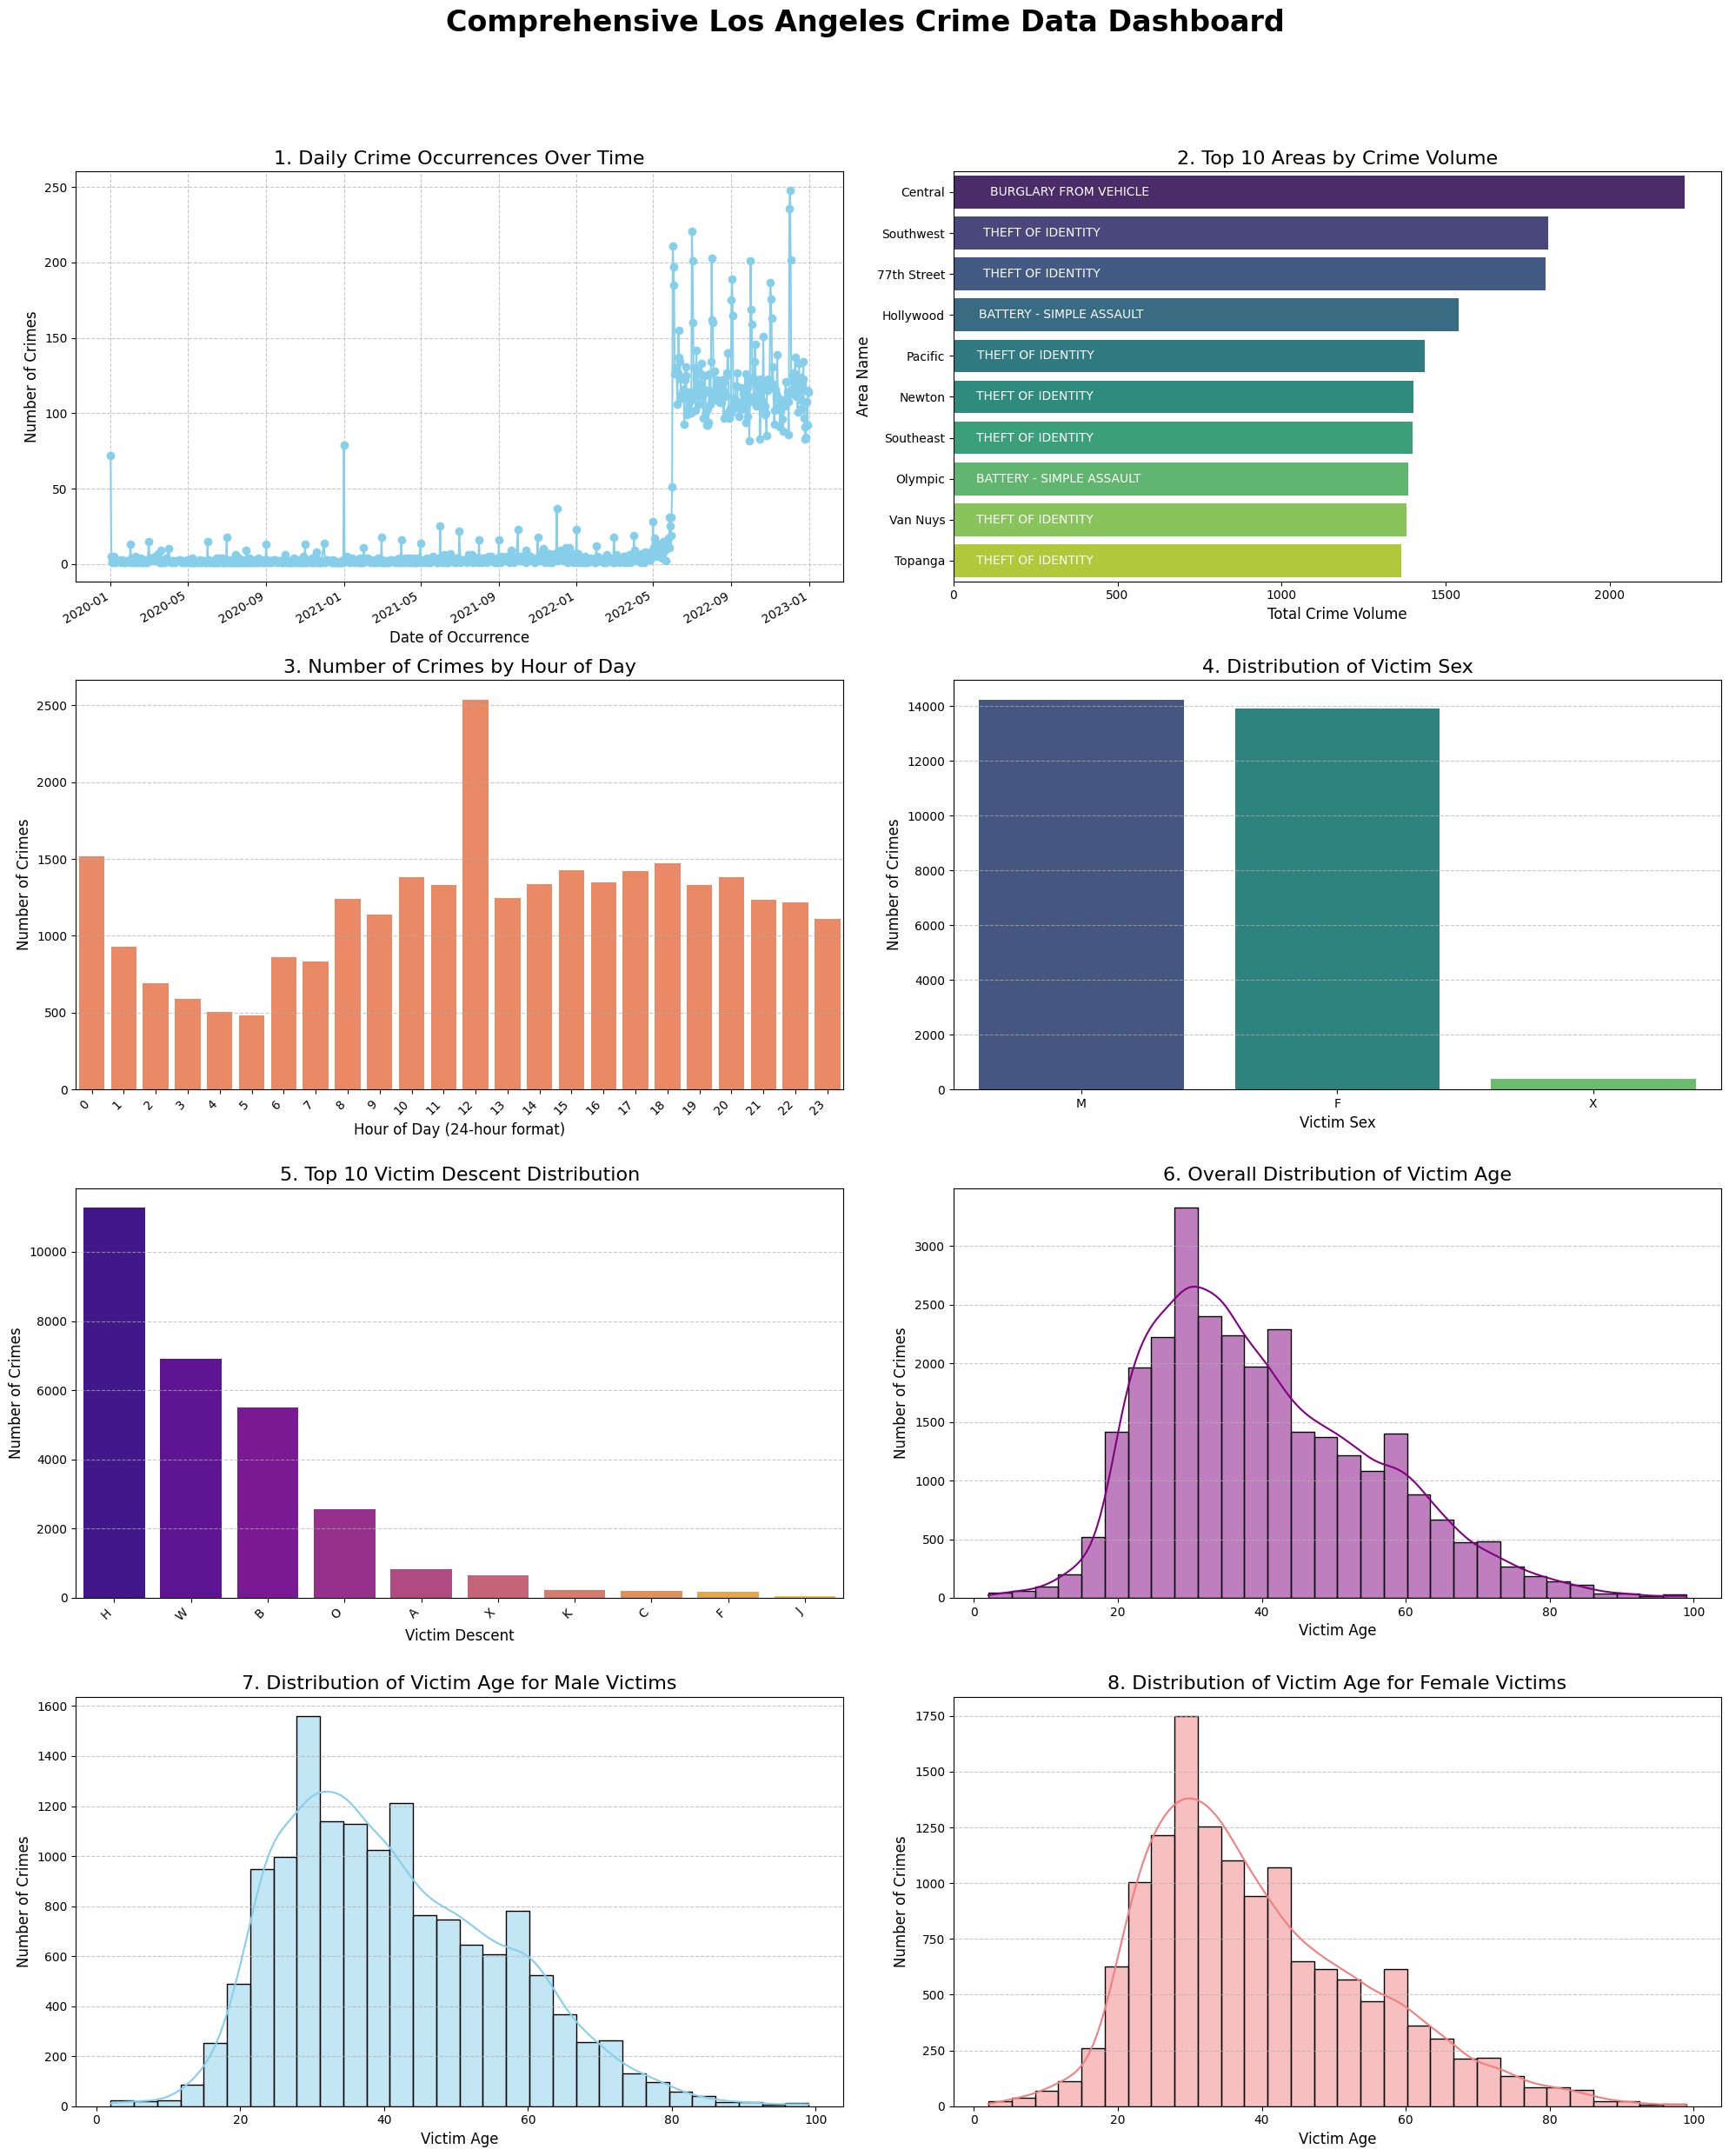

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset (this was the missing step causing the NameError)
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})

# Data preprocessing for plots (re-running essential steps to ensure variables exist)
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
crimes['TIME OCC'] = crimes['TIME OCC'].astype(str).str.zfill(4)
crimes['HOUR OCC'] = crimes['TIME OCC'].str[:2].astype(int)
crimes['Vict Sex'] = crimes['Vict Sex'].replace('H', 'X')
crimes['Vict Sex'].fillna('X', inplace=True) # Fill any remaining NaN if not already handled
crimes['Weapon Desc'].fillna('Unidentified Weapon', inplace=True) # Fill any remaining NaN if not already handled

# 1. Daily Crime Occurrences Over Time (from cell_id: 3b41d2d5)
daily_crime_counts = crimes['DATE OCC'].value_counts().sort_index()

# 2. Top 10 Areas by Crime Volume (from cell_id: 2skEp_QnwE7s)
area_crime_counts = crimes['AREA NAME'].value_counts()
top_10_areas = area_crime_counts.head(10)
plot_data = []
for area in top_10_areas.index:
    crimes_in_area = crimes[crimes['AREA NAME'] == area]
    if not crimes_in_area.empty:
        most_prevalent_crime = crimes_in_area['Crm Cd Desc'].mode()[0]
        plot_data.append({'Area': area, 'Total Crimes': top_10_areas[area], 'Most Prevalent Crime': most_prevalent_crime})
plot_df = pd.DataFrame(plot_data)

# 3. Victim Sex Distribution (from cell_id: UGIXeCej-cku)
vict_sex_counts = crimes['Vict Sex'].value_counts()

# 4. Victim Descent Distribution (from cell_id: UGIXeCej-cku)
vict_descent_counts = crimes['Vict Descent'].value_counts().head(10)

# Create a figure with multiple subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 25))
fig.suptitle('Comprehensive Los Angeles Crime Data Dashboard', fontsize=24, fontweight='bold', y=1.02)

# Plot 1: Daily Crime Occurrences Over Time
axes[0, 0].plot(daily_crime_counts.index, daily_crime_counts.values, marker='o', linestyle='-', color='skyblue')
axes[0, 0].set_title('1. Daily Crime Occurrences Over Time', fontsize=16)
axes[0, 0].set_xlabel('Date of Occurrence', fontsize=12)
axes[0, 0].set_ylabel('Number of Crimes', fontsize=12)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
plt.setp(axes[0, 0].get_xticklabels(), rotation=30, ha='right')

# Plot 2: Top 10 Areas by Crime Volume and Most Prevalent Crime Type
sns.barplot(x='Total Crimes', y='Area', data=plot_df, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. Top 10 Areas by Crime Volume', fontsize=16)
axes[0, 1].set_xlabel('Total Crime Volume', fontsize=12)
axes[0, 1].set_ylabel('Area Name', fontsize=12)
for index, row in plot_df.iterrows():
    axes[0, 1].text(row['Total Crimes'] * 0.05, index, row['Most Prevalent Crime'], color='white', ha="left", va="center", fontsize=10)

# Plot 3: Number of Crimes by Hour of Day
hourly_crime_counts = crimes['HOUR OCC'].value_counts().sort_index()
sns.barplot(x=hourly_crime_counts.index, y=hourly_crime_counts.values, color='coral', ax=axes[1, 0])
axes[1, 0].set_title('3. Number of Crimes by Hour of Day', fontsize=16)
axes[1, 0].set_xlabel('Hour of Day (24-hour format)', fontsize=12)
axes[1, 0].set_ylabel('Number of Crimes', fontsize=12)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# Plot 4: Distribution of Victim Sex
sns.barplot(x=vict_sex_counts.index, y=vict_sex_counts.values, palette='viridis', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('4. Distribution of Victim Sex', fontsize=16)
axes[1, 1].set_xlabel('Victim Sex', fontsize=12)
axes[1, 1].set_ylabel('Number of Crimes', fontsize=12)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 5: Top 10 Victim Descent Distribution
sns.barplot(x=vict_descent_counts.index, y=vict_descent_counts.values, palette='plasma', legend=False, ax=axes[2, 0])
axes[2, 0].set_title('5. Top 10 Victim Descent Distribution', fontsize=16)
axes[2, 0].set_xlabel('Victim Descent', fontsize=12)
axes[2, 0].set_ylabel('Number of Crimes', fontsize=12)
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.7)
plt.setp(axes[2, 0].get_xticklabels(), rotation=45, ha='right')

# Plot 6: Overall Distribution of Victim Age
sns.histplot(data=crimes, x='Vict Age', bins=30, kde=True, color='purple', ax=axes[2, 1])
axes[2, 1].set_title('6. Overall Distribution of Victim Age', fontsize=16)
axes[2, 1].set_xlabel('Victim Age', fontsize=12)
axes[2, 1].set_ylabel('Number of Crimes', fontsize=12)
axes[2, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 7: Distribution of Victim Age for Male Victims
sns.histplot(data=crimes[crimes['Vict Sex'] == 'M'], x='Vict Age', bins=30, kde=True, color='skyblue', ax=axes[3, 0])
axes[3, 0].set_title('7. Distribution of Victim Age for Male Victims', fontsize=16)
axes[3, 0].set_xlabel('Victim Age', fontsize=12)
axes[3, 0].set_ylabel('Number of Crimes', fontsize=12)
axes[3, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 8: Distribution of Victim Age for Female Victims
sns.histplot(data=crimes[crimes['Vict Sex'] == 'F'], x='Vict Age', bins=30, kde=True, color='lightcoral', ax=axes[3, 1])
axes[3, 1].set_title('8. Distribution of Victim Age for Female Victims', fontsize=16)
axes[3, 1].set_xlabel('Victim Age', fontsize=12)
axes[3, 1].set_ylabel('Number of Crimes', fontsize=12)
axes[3, 1].grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()